In [1]:
#!/bin/bash
!curl -L -o it-service-ticket-classification-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/adisongoh/it-service-ticket-classification-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3530k  100 3530k    0     0  7916k      0 --:--:-- --:--:-- --:--:-- 7916k


In [2]:
!unzip /content/it-service-ticket-classification-dataset.zip

Archive:  /content/it-service-ticket-classification-dataset.zip
  inflating: all_tickets_processed_improved_v3.csv  


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/all_tickets_processed_improved_v3.csv')

In [5]:
df

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous
...,...,...
47832,git space for a project issues with adding use...,Access
47833,error sent july error hi guys can you help out...,Miscellaneous
47834,connection issues sent tuesday july connection...,Hardware
47835,error cube reports sent tuesday july error hel...,HR Support


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


In [7]:
df.isnull().sum().sum()

np.int64(0)

In [8]:
df['char_count'] = df['Document'].astype(str).apply(len)

In [10]:
df['word_count'] = df['Document'].astype(str).apply(lambda x: len(x.split()))

In [16]:
df.head()

,Document,Topic_group,char_count,word_count
0,connection with icon icon dear please setup ic...,Hardware,111,18
1,work experience user work experience user hi w...,Access,124,19
2,requesting for meeting requesting meeting hi p...,Hardware,93,14
3,reset passwords for external accounts re expir...,Access,948,145
4,mail verification warning hi has got attached ...,Miscellaneous,115,15


In [11]:
df[['char_count', 'word_count']].describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,47837.0,291.881263,388.1712,7.0,110.0,175.0,304.0,7015.0
word_count,47837.0,43.597341,56.7368,2.0,17.0,26.0,46.0,981.0


/tmp/ipykernel_14026/3390006949.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Topic_group', data=df, order=df['Topic_group'].value_counts().index, palette='viridis')


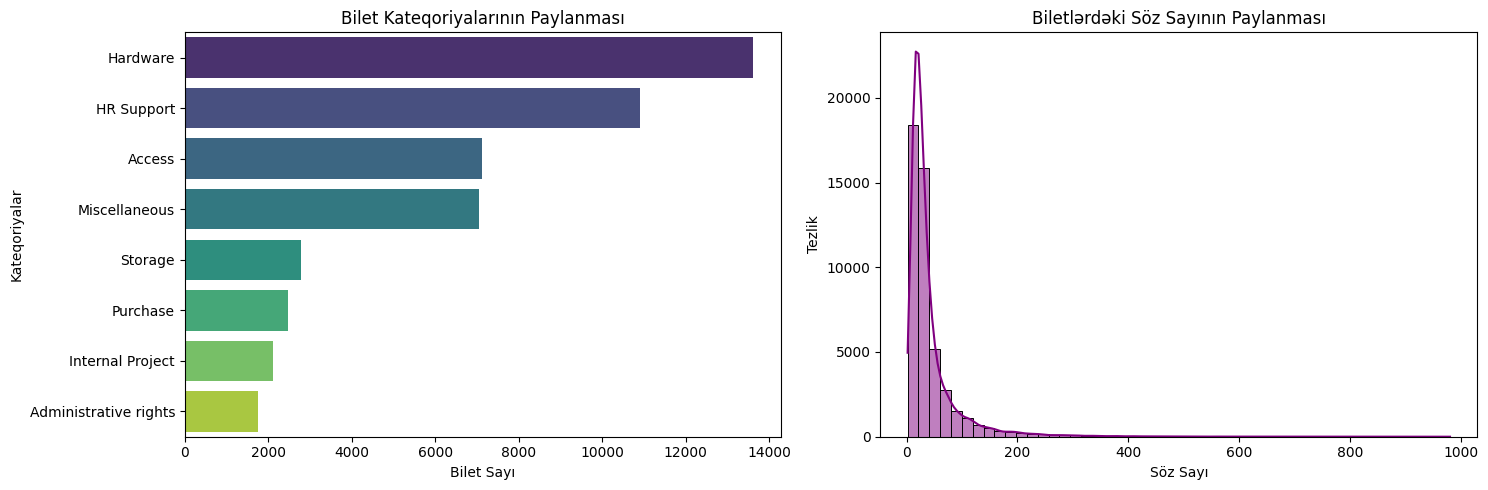

In [13]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(y='Topic_group', data=df, order=df['Topic_group'].value_counts().index, palette='viridis')
plt.title('Bilet Kateqoriyalarının Paylanması')
plt.xlabel('Bilet Sayı')
plt.ylabel('Kateqoriyalar')

plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=50, kde=True, color='purple')
plt.title('Biletlərdəki Söz Sayının Paylanması')
plt.xlabel('Söz Sayı')
plt.ylabel('Tezlik')

plt.tight_layout()
plt.show()

In [18]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
  if pd.isnull(text):
    return ""

  text = text.lower()

  text = re.sub(r'[^a-zA-Z\s]', '', text)

  words = word_tokenize(text)

  cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

  return " ".join(cleaned_words)

df['Cleaned_Document'] = df['Document'].apply(clean_text)

In [24]:
for i in range(3):
  print("Documents")
  print(df['Document'].iloc[i])
  print()
  print("Cleaned Documents")
  print(df['Cleaned_Document'].iloc[i])
  print()

Documents
connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

Cleaned Documents
connection icon icon dear please setup icon per icon engineer please let detail needed thanks lead

Documents
work experience user work experience user hi work experience student coming next his name much appreciate him duration thank

Cleaned Documents
work experience user work experience user hi work experience student coming next name much appreciate duration thank

Documents
requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug

Cleaned Documents
requesting meeting requesting meeting hi please help follow equipment cable pc cord plug



In [25]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import scipy.sparse as sp

In [26]:
df.isnull().sum()

,0
Document,0
Topic_group,0
char_count,0
word_count,0
Cleaned_Document,0


In [27]:
le = LabelEncoder()
df['Topic_group'] = le.fit_transform(df['Topic_group'])

for index, class_name in enumerate(le.classes_):
  print(f"{index} -> {class_name}")

0 -> Access
1 -> Administrative rights
2 -> HR Support
3 -> Hardware
4 -> Internal Project
5 -> Miscellaneous
6 -> Purchase
7 -> Storage


In [28]:
X = df['Cleaned_Document']

y = df['Topic_group']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
X_train.shape

(38269,)

In [31]:
X_test.shape

(9568,)

In [32]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [33]:
X_train_tfidf.shape

(38269, 5000)

In [35]:
X_test_tfidf.shape

(9568, 5000)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [38]:
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1),
    "Linear SVM": LinearSVC(class_weight='balanced', random_state=42)
}

model_results = {}

for model_name, model in models.items():
  model.fit(X_train_tfidf, y_train)

  y_pred = model.predict(X_test_tfidf)

  acc = accuracy_score(y_test, y_pred)
  model_results[model_name] = acc

  print(f"{model_name} -> {acc}")

Logistic Regression -> 0.8440635451505016
Decision Tree -> 0.7488503344481605
Random Forest -> 0.8396739130434783
Linear SVM -> 0.8445861204013378


In [39]:
for name, score in model_results.items():
  print(f"{name} -> {score}")

Logistic Regression -> 0.8440635451505016
Decision Tree -> 0.7488503344481605
Random Forest -> 0.8396739130434783
Linear SVM -> 0.8445861204013378


In [40]:
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
best_model = models['Linear SVM']
y_pred_svm = best_model.predict(X_test_tfidf)

In [42]:
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

                       precision    recall  f1-score   support

               Access       0.88      0.89      0.89      1425
Administrative rights       0.68      0.76      0.72       352
           HR Support       0.87      0.83      0.85      2183
             Hardware       0.85      0.81      0.83      2724
     Internal Project       0.82      0.92      0.87       424
        Miscellaneous       0.80      0.84      0.82      1412
             Purchase       0.89      0.89      0.89       493
              Storage       0.85      0.91      0.88       555

             accuracy                           0.84      9568
            macro avg       0.83      0.86      0.84      9568
         weighted avg       0.85      0.84      0.84      9568



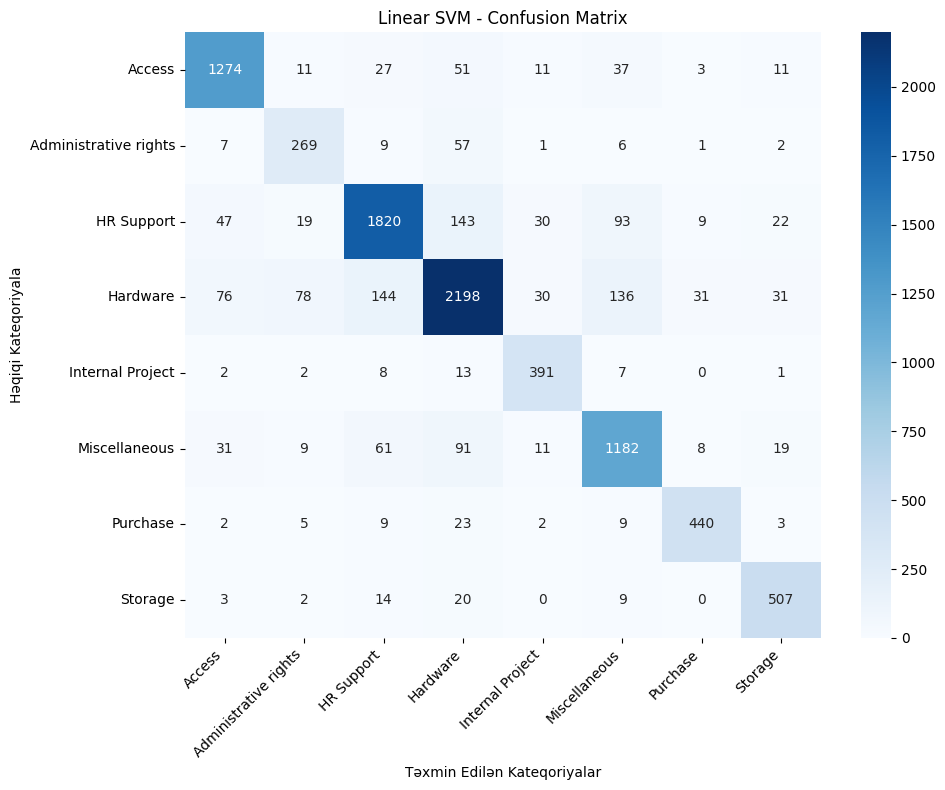

In [43]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title('Linear SVM - Confusion Matrix')
plt.ylabel('Həqiqi Kateqoriyala')
plt.xlabel('Təxmin Edilən Kateqoriyalar')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()